In [38]:
import pandas as pd
import os
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
proj_csv_linear = pd.read_csv('/home/fsoto/Documents/LCsSSL/wandb_csv/linear_projection_ablation.csv')
proj_csv_mlp = pd.read_csv('/home/fsoto/Documents/LCsSSL/wandb_csv/mlp_projection_ablation.csv')

In [40]:
def find_config(pre_trained_lc_path, pre_trained_iteration):

    config_file = os.path.join(pre_trained_lc_path,str(pre_trained_iteration),'.hydra','config.yaml')
    #add to the name instead of train to final_train
    config_file = config_file.replace('train','backup/vicreg_simclr')
    #remove /multiruns
    config_file = config_file.replace('/multiruns','')
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
    proj = config['model']['projector']['projection_size']
    return proj


In [41]:
proj_csv_linear['projection_size'] = proj_csv_linear.apply(lambda row: find_config(
    pre_trained_lc_path=row['model.pre_trained_lc_path'],
    pre_trained_iteration=row['model.pre_trained_iteration']), axis=1)

proj_csv_mlp['projection_size'] = proj_csv_mlp.apply(lambda row: find_config(
    pre_trained_lc_path=row['model.pre_trained_lc_path'],
    pre_trained_iteration=row['model.pre_trained_iteration']), axis=1)

In [42]:
#calculate the mean f1 and std grouped by projection_size
proj_csv_grouped_linear = proj_csv_linear.groupby('projection_size').agg({'val/f1': ['mean', 'std']}).reset_index()
proj_csv_grouped_linear.columns = ['projection_size', 'f1_mean', 'f1_std']

proj_csv_grouped_mlp = proj_csv_mlp.groupby('projection_size').agg({'val/f1': ['mean', 'std']}).reset_index()
proj_csv_grouped_mlp.columns = ['projection_size', 'f1_mean', 'f1_std']

In [43]:
proj_csv_grouped_mlp

,projection_size,f1_mean,f1_std
0,128,0.653832,0.006311
1,256,0.663619,0.005866
2,512,0.672998,0.004606
3,1024,0.681990,0.006197
4,2048,0.684993,0.006934
5,4096,0.688739,0.004558


In [44]:
proj_csv_grouped_linear['type'] = 'Linear Projector'
proj_csv_grouped_mlp['type'] = 'MLP Projector'
plot_df = pd.concat([proj_csv_grouped_linear, proj_csv_grouped_mlp], ignore_index=True)



In [45]:
sns.set_theme(style='whitegrid', context='talk')

ordered_sizes = sorted(plot_df['projection_size'].unique())
sorted_df = plot_df.sort_values(['projection_size', 'type'])
palette = sns.color_palette('colorblind', n_colors=sorted_df['type'].nunique())



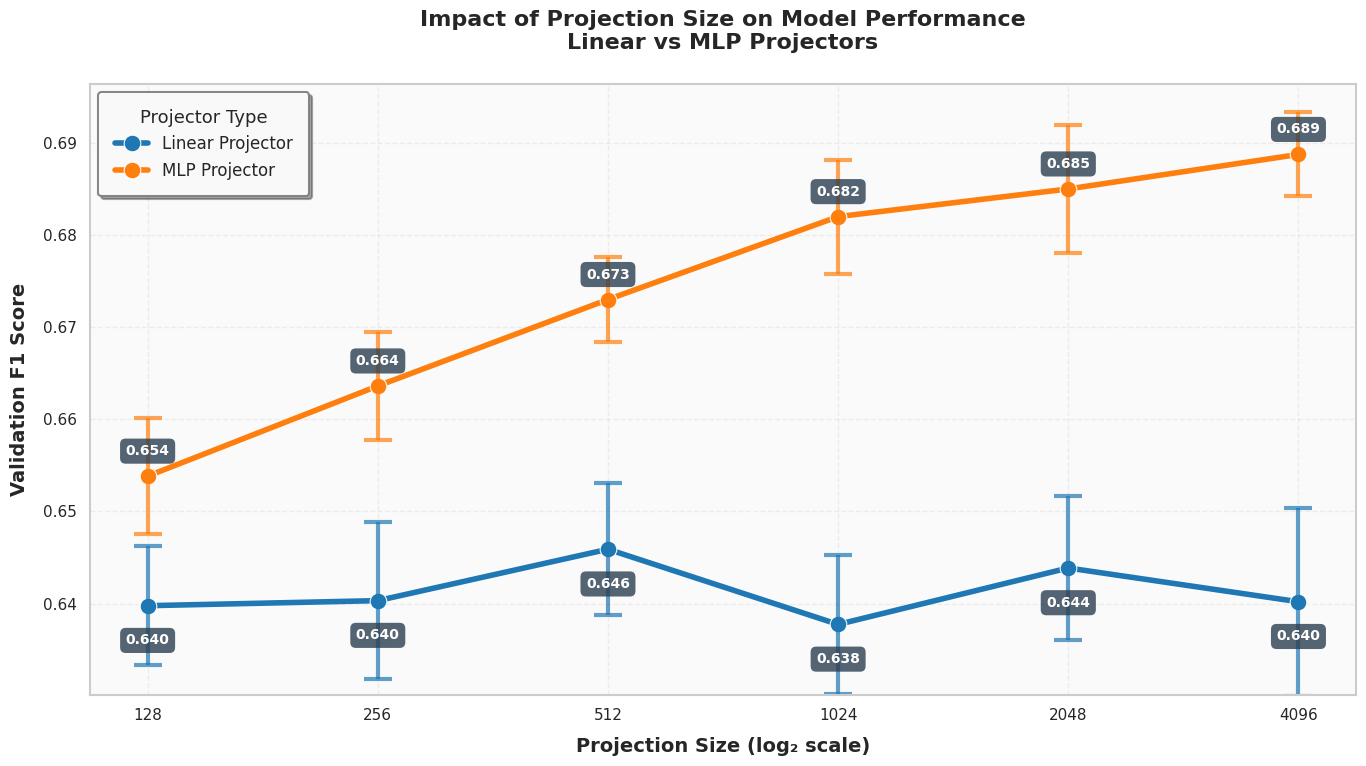

In [46]:
fig, ax = plt.subplots(figsize=(14, 8))

# Create the line plot with improved styling
sns.lineplot(
    data=sorted_df,
    x='projection_size',
    y='f1_mean',
    hue='type',
    hue_order=['Linear Projector', 'MLP Projector'],
    palette=['#1f77b4', '#ff7f0e'],  # More distinct colors
    marker='o',
    markersize=12,
    linewidth=4,
    ax=ax
)

# Add error bars with improved styling
colors = ['#1f77b4', '#ff7f0e']
for color, projector_type in zip(colors, ['Linear Projector', 'MLP Projector']):
    subset = sorted_df[sorted_df['type'] == projector_type]
    ax.errorbar(
        subset['projection_size'],
        subset['f1_mean'],
        yerr=subset['f1_std'],
        fmt='none',
        c=color,
        capsize=10,
        capthick=3,
        linewidth=3,
        alpha=0.7
    )

# Add value annotations with improved positioning and styling
for _, row in sorted_df.iterrows():
    offset_y = 18 if row['type'] == 'MLP Projector' else -25
    ax.annotate(
        f"{row['f1_mean']:.3f}",
        xy=(row['projection_size'], row['f1_mean']),
        textcoords='offset points',
        xytext=(0, offset_y),
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.4', 
            facecolor='#2c3e50', 
            edgecolor='none', 
            alpha=0.8
        )
    )

# Improve axes formatting
ax.set_xscale('log', base=2)
ax.set_xticks(ordered_sizes)
ax.set_xticklabels([f'{size}' for size in ordered_sizes], fontsize=12)
ax.set_xlabel('Projection Size (log₂ scale)', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('Validation F1 Score', fontsize=14, fontweight='bold', labelpad=10)
ax.set_title('Impact of Projection Size on Model Performance\nLinear vs MLP Projectors', 
             fontsize=16, fontweight='bold', pad=25)

# Improve y-axis limits with better margins
y_min, y_max = sorted_df['f1_mean'].min(), sorted_df['f1_mean'].max()
y_range = y_max - y_min
margin = y_range * 0.15
ax.set_ylim(y_min - margin, y_max + margin)

# Enhanced grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.set_axisbelow(True)

# Improve legend with better positioning and styling
legend = ax.legend(
    title='Projector Type', 
    loc='upper left', 
    frameon=True,
    fancybox=True, 
    shadow=True, 
    fontsize=12, 
    title_fontsize=13,
    borderpad=1,
    columnspacing=1,
    handlelength=2
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)
legend.get_frame().set_edgecolor('gray')

# Add subtle background and spine styling
ax.set_facecolor('#fafafa')
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#cccccc')

# Improve tick styling
ax.tick_params(axis='both', which='major', labelsize=11, width=1.5, length=6)
ax.tick_params(axis='both', which='minor', width=1, length=3)

plt.tight_layout()
plt.savefig('projection_size_ablation_improved.pdf', dpi=300, bbox_inches='tight')
plt.show()

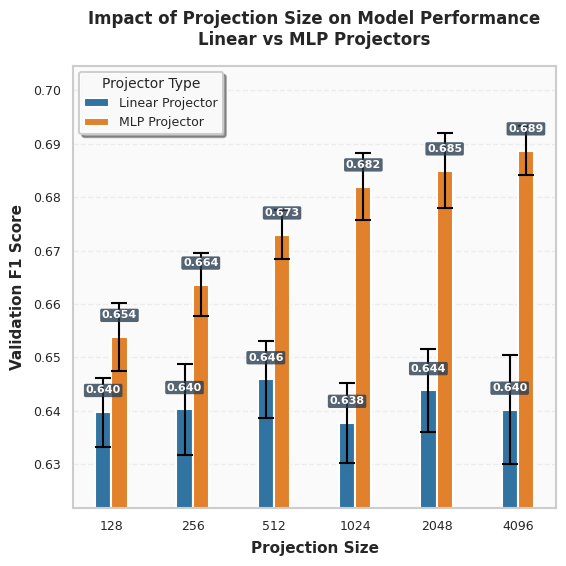

In [47]:
fig, ax = plt.subplots(figsize=(6, 6))

# Create the bar plot with thinner bars and closer spacing
sns.barplot(
    data=sorted_df,
    x='projection_size',
    y='f1_mean',
    hue='type',
    hue_order=['Linear Projector', 'MLP Projector'],
    palette=['#1f77b4', '#ff7f0e'],
    ax=ax,
    width=0.4  # Much thinner bars
)

# Add error bars manually with adjusted positions for closer bars
for i, size in enumerate(ordered_sizes):
    # Get positions for each projection size group (much closer spacing)
    linear_pos = i - 0.1  # Closer bars
    mlp_pos = i + 0.1     # Closer bars
    
    # Add error bars for Linear Projector
    linear_data = sorted_df[(sorted_df['projection_size'] == size) & (sorted_df['type'] == 'Linear Projector')]
    if not linear_data.empty:
        ax.errorbar(
            linear_pos, linear_data['f1_mean'].iloc[0], 
            yerr=linear_data['f1_std'].iloc[0],
            fmt='none', c='black', capsize=6, capthick=1.5, linewidth=1.5,
            elinewidth=1.5, markeredgewidth=1.5
        )
    
    # Add error bars for MLP Projector
    mlp_data = sorted_df[(sorted_df['projection_size'] == size) & (sorted_df['type'] == 'MLP Projector')]
    if not mlp_data.empty:
        ax.errorbar(
            mlp_pos, mlp_data['f1_mean'].iloc[0], 
            yerr=mlp_data['f1_std'].iloc[0],
            fmt='none', c='black', capsize=6, capthick=1.5, linewidth=1.5,
            elinewidth=1.5, markeredgewidth=1.5
        )

# Add value annotations with adjusted positions
for i, size in enumerate(ordered_sizes):
    linear_data = sorted_df[(sorted_df['projection_size'] == size) & (sorted_df['type'] == 'Linear Projector')]
    mlp_data = sorted_df[(sorted_df['projection_size'] == size) & (sorted_df['type'] == 'MLP Projector')]
    
    if not linear_data.empty:
        ax.annotate(
            f"{linear_data['f1_mean'].iloc[0]:.3f}",
            xy=(i - 0.1, linear_data['f1_mean'].iloc[0]),
            textcoords='offset points',
            xytext=(0, 12),
            ha='center', va='bottom',
            fontsize=8, fontweight='bold',
            color='white',
            bbox=dict(
                boxstyle='round,pad=0.15', 
                facecolor='#2c3e50', 
                edgecolor='none', 
                alpha=0.8
            )
        )
    
    if not mlp_data.empty:
        ax.annotate(
            f"{mlp_data['f1_mean'].iloc[0]:.3f}",
            xy=(i + 0.1, mlp_data['f1_mean'].iloc[0]),
            textcoords='offset points',
            xytext=(0, 12),
            ha='center', va='bottom',
            fontsize=8, fontweight='bold',
            color='white',
            bbox=dict(
                boxstyle='round,pad=0.15', 
                facecolor='#2c3e50', 
                edgecolor='none', 
                alpha=0.8
            )
        )

# Formatting
ax.set_xlabel('Projection Size', fontsize=11, fontweight='bold', labelpad=6)
ax.set_ylabel('Validation F1 Score', fontsize=11, fontweight='bold', labelpad=6)
ax.set_title('Impact of Projection Size on Model Performance\nLinear vs MLP Projectors', 
             fontsize=12, fontweight='bold', pad=15)

# Set tighter y-axis limits
y_min_data = sorted_df['f1_mean'].min() - sorted_df['f1_std'].max()
y_max_data = sorted_df['f1_mean'].max() + sorted_df['f1_std'].max()
y_range = y_max_data - y_min_data
small_margin = y_range * 0.08
ax.set_ylim(y_min_data - small_margin, y_max_data + small_margin)

# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1, axis='y')
ax.set_axisbelow(True)

# Legend
legend = ax.legend(
    title='Projector Type', 
    loc='upper left', 
    frameon=True,
    fancybox=True, 
    shadow=True, 
    fontsize=9, 
    title_fontsize=10
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)

# Styling
ax.set_facecolor('#fafafa')
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#cccccc')

ax.tick_params(axis='both', which='major', labelsize=9, width=1.5, length=5)

plt.tight_layout()
plt.show()

In [48]:
# Perform pairwise permutation tests for Linear Projector
import numpy as np
from mlxtend.evaluate import permutation_test

# Configuration
N_RESAMPLES = 10000
SIGNIFICANCE_LEVEL = 0.05

# Function to get F1 scores for a specific projection size
def get_f1_scores_for_projection(df, projection_size_value):
    """Get all F1 scores for a specific projection size"""
    matching_scores = df[df['projection_size'] == projection_size_value].sort_values(by='data.split')['val/f1'].values
    return np.array(matching_scores)

# Perform pairwise permutation tests for Linear Projector
projection_sizes = sorted(proj_csv_linear['projection_size'].unique())
n_projections = len(projection_sizes)
results_linear = []

print(f"PAIRWISE PERMUTATION TEST ANALYSIS - LINEAR PROJECTOR")
print(f"=" * 70)
print(f"Number of projection sizes: {n_projections}")
print(f"Total pairwise comparisons: {n_projections * (n_projections - 1)}")
print(f"Resamples: {N_RESAMPLES:,}")
print(f"Significance level: α = {SIGNIFICANCE_LEVEL}")
print(f"\nStarting analysis...\n")

from time import time
start_time = time()

for i in range(n_projections):
    for j in range(n_projections):
        if i == j:
            continue
        proj_i = projection_sizes[i]
        proj_j = projection_sizes[j]
        
        scores_i = get_f1_scores_for_projection(proj_csv_linear, proj_i)
        scores_j = get_f1_scores_for_projection(proj_csv_linear, proj_j)
        
        if len(scores_i) > 1 and len(scores_j) > 1:
            # Perform permutation test
            p_value = permutation_test(
                scores_i, 
                scores_j,
                func='x_mean > y_mean',
                method='approximate',
                num_rounds=N_RESAMPLES,
                paired=True
            )
            
            # Calculate effect size (Cohen's d)
            pooled_std = np.sqrt((np.var(scores_i) + np.var(scores_j)) / 2)
            effect_size = (np.mean(scores_i) - np.mean(scores_j)) / pooled_std if pooled_std > 0 else 0
            
            results_linear.append({
                'projection_size_1': proj_i,
                'projection_size_2': proj_j,
                'mean_f1_1': np.mean(scores_i),
                'mean_f1_2': np.mean(scores_j),
                'std_f1_1': np.std(scores_i),
                'std_f1_2': np.std(scores_j),
                'p_value': p_value,
                'significant': p_value < SIGNIFICANCE_LEVEL,
                'effect_size': effect_size,
                'n_samples_1': len(scores_i),
                'n_samples_2': len(scores_j)
            })

comparison_results_linear = pd.DataFrame(results_linear)
elapsed_time = time() - start_time

print(f"\n✓ ANALYSIS COMPLETE in {elapsed_time:.1f}s")
print(f"=" * 70)
print(f"Speed: {len(comparison_results_linear)/elapsed_time:.1f} comparisons/sec")
print(f"Significant: {comparison_results_linear['significant'].sum()}/{len(comparison_results_linear)} "
      f"({100*comparison_results_linear['significant'].sum()/len(comparison_results_linear):.1f}%)")

print(f"\nTOP SIGNIFICANT DIFFERENCES:")
if comparison_results_linear['significant'].sum() > 0:
    for idx, row in comparison_results_linear[comparison_results_linear['significant']].sort_values('p_value').iterrows():
        print(f"  Projection {row['projection_size_1']} vs {row['projection_size_2']}: p={row['p_value']:.4f}, d={row['effect_size']:.2f}")
else:
    print("  No significant differences found")




PAIRWISE PERMUTATION TEST ANALYSIS - LINEAR PROJECTOR
Number of projection sizes: 6
Total pairwise comparisons: 30
Resamples: 10,000
Significance level: α = 0.05

Starting analysis...


✓ ANALYSIS COMPLETE in 9.7s
Speed: 3.1 comparisons/sec
Significant: 8/30 (26.7%)

TOP SIGNIFICANT DIFFERENCES:
  Projection 512 vs 128: p=0.0001, d=0.92
  Projection 512 vs 1024: p=0.0001, d=1.13
  Projection 2048 vs 1024: p=0.0002, d=0.81
  Projection 512 vs 256: p=0.0004, d=0.72
  Projection 512 vs 4096: p=0.0054, d=0.66
  Projection 2048 vs 128: p=0.0106, d=0.58
  Projection 2048 vs 256: p=0.0108, d=0.44
  Projection 2048 vs 4096: p=0.0392, d=0.41

✓ ANALYSIS COMPLETE in 9.7s
Speed: 3.1 comparisons/sec
Significant: 8/30 (26.7%)

TOP SIGNIFICANT DIFFERENCES:
  Projection 512 vs 128: p=0.0001, d=0.92
  Projection 512 vs 1024: p=0.0001, d=1.13
  Projection 2048 vs 1024: p=0.0002, d=0.81
  Projection 512 vs 256: p=0.0004, d=0.72
  Projection 512 vs 4096: p=0.0054, d=0.66
  Projection 2048 vs 128: p=0.010

In [50]:
# Perform pairwise permutation tests for MLP Projector
results_mlp = []

print(f"PAIRWISE PERMUTATION TEST ANALYSIS - MLP PROJECTOR")
print(f"=" * 70)
print(f"Number of projection sizes: {n_projections}")
print(f"Total pairwise comparisons: {n_projections * (n_projections - 1)}")
print(f"Resamples: {N_RESAMPLES:,}")
print(f"Significance level: α = {SIGNIFICANCE_LEVEL}")
print(f"\nStarting analysis...\n")

start_time = time()

for i in range(n_projections):
    for j in range(n_projections):
        if i == j:
            continue
        proj_i = projection_sizes[i]
        proj_j = projection_sizes[j]
        
        scores_i = get_f1_scores_for_projection(proj_csv_mlp, proj_i)
        scores_j = get_f1_scores_for_projection(proj_csv_mlp, proj_j)
        
        if len(scores_i) > 1 and len(scores_j) > 1:
            # Perform permutation test
            p_value = permutation_test(
                scores_i, 
                scores_j,
                func='x_mean > y_mean',
                method='approximate',
                num_rounds=N_RESAMPLES,
                paired=True
            )
            
            # Calculate effect size (Cohen's d)
            pooled_std = np.sqrt((np.var(scores_i) + np.var(scores_j)) / 2)
            effect_size = (np.mean(scores_i) - np.mean(scores_j)) / pooled_std if pooled_std > 0 else 0
            
            results_mlp.append({
                'projection_size_1': proj_i,
                'projection_size_2': proj_j,
                'mean_f1_1': np.mean(scores_i),
                'mean_f1_2': np.mean(scores_j),
                'std_f1_1': np.std(scores_i),
                'std_f1_2': np.std(scores_j),
                'p_value': p_value,
                'significant': p_value < SIGNIFICANCE_LEVEL,
                'effect_size': effect_size,
                'n_samples_1': len(scores_i),
                'n_samples_2': len(scores_j)
            })

comparison_results_mlp = pd.DataFrame(results_mlp)
elapsed_time = time() - start_time

print(f"\n✓ ANALYSIS COMPLETE in {elapsed_time:.1f}s")
print(f"=" * 70)
print(f"Speed: {len(comparison_results_mlp)/elapsed_time:.1f} comparisons/sec")
print(f"Significant: {comparison_results_mlp['significant'].sum()}/{len(comparison_results_mlp)} "
      f"({100*comparison_results_mlp['significant'].sum()/len(comparison_results_mlp):.1f}%)")

print(f"\nTOP SIGNIFICANT DIFFERENCES:")
if comparison_results_mlp['significant'].sum() > 0:
    for idx, row in comparison_results_mlp[comparison_results_mlp['significant']].sort_values('p_value').iterrows():
        print(f"  Projection {row['projection_size_1']} vs {row['projection_size_2']}: p={row['p_value']:.4f}, d={row['effect_size']:.2f}")
else:
    print("  No significant differences found")



PAIRWISE PERMUTATION TEST ANALYSIS - MLP PROJECTOR
Number of projection sizes: 6
Total pairwise comparisons: 30
Resamples: 10,000
Significance level: α = 0.05

Starting analysis...


✓ ANALYSIS COMPLETE in 9.4s
Speed: 3.2 comparisons/sec
Significant: 15/30 (50.0%)

TOP SIGNIFICANT DIFFERENCES:
  Projection 256 vs 128: p=0.0001, d=1.64
  Projection 512 vs 128: p=0.0001, d=3.54
  Projection 512 vs 256: p=0.0001, d=1.82
  Projection 1024 vs 128: p=0.0001, d=4.60
  Projection 1024 vs 256: p=0.0001, d=3.11
  Projection 1024 vs 512: p=0.0001, d=1.68
  Projection 2048 vs 128: p=0.0001, d=4.80
  Projection 2048 vs 256: p=0.0001, d=3.40
  Projection 2048 vs 512: p=0.0001, d=2.08
  Projection 4096 vs 128: p=0.0001, d=6.47
  Projection 4096 vs 256: p=0.0001, d=4.88
  Projection 4096 vs 512: p=0.0001, d=3.51
  Projection 4096 vs 1024: p=0.0001, d=1.27
  Projection 4096 vs 2048: p=0.0059, d=0.65
  Projection 2048 vs 1024: p=0.0180, d=0.47

✓ ANALYSIS COMPLETE in 9.4s
Speed: 3.2 comparisons/sec
Sign

In [51]:
# Export results to CSV for Linear Projector
output_path_linear = '/home/fsoto/Documents/LCsSSL/wandb_csv/linear_projection_ablation_results.csv'

# Create summary with mean ± std format
summary_results_linear = []
for proj_size in projection_sizes:
    proj_data = proj_csv_grouped_linear[proj_csv_grouped_linear['projection_size'] == proj_size].iloc[0]
    
    # Count how many projection sizes this one is significantly better than
    sig_better = comparison_results_linear[
        (comparison_results_linear['projection_size_1'] == proj_size) &
        (comparison_results_linear['significant'] == True) &
        (comparison_results_linear['effect_size'] > 0)
    ]
    
    summary_results_linear.append({
        'Projection_Size': proj_size,
        'F1_Mean': proj_data['f1_mean'],
        'F1_Std': proj_data['f1_std'],
        'Count': len(proj_csv_linear[proj_csv_linear['projection_size'] == proj_size]),
        'Num_Significantly_Better_Than': len(sig_better)
    })

summary_df_linear = pd.DataFrame(summary_results_linear)
summary_df_linear = summary_df_linear.sort_values(by='F1_Mean', ascending=False)
summary_df_linear.to_csv(output_path_linear, index=False, float_format='%.6f')

print(f"✓ Linear Projector summary results saved to: {output_path_linear}")
print(f"  Rows: {len(summary_df_linear)}")
print(f"\nLinear Projector Summary:")
print(summary_df_linear.to_string(index=False))

# Also save detailed pairwise comparisons
detailed_output_path_linear = '/home/fsoto/Documents/LCsSSL/wandb_csv/linear_projection_ablation_pairwise.csv'
comparison_results_linear.to_csv(detailed_output_path_linear, index=False, float_format='%.6f')
print(f"\n✓ Detailed pairwise comparisons saved to: {detailed_output_path_linear}")

# Export results to CSV for MLP Projector
output_path_mlp = '/home/fsoto/Documents/LCsSSL/wandb_csv/mlp_projection_ablation_results.csv'

# Create summary with mean ± std format
summary_results_mlp = []
for proj_size in projection_sizes:
    proj_data = proj_csv_grouped_mlp[proj_csv_grouped_mlp['projection_size'] == proj_size].iloc[0]
    
    # Count how many projection sizes this one is significantly better than
    sig_better = comparison_results_mlp[
        (comparison_results_mlp['projection_size_1'] == proj_size) &
        (comparison_results_mlp['significant'] == True) &
        (comparison_results_mlp['effect_size'] > 0)
    ]
    
    summary_results_mlp.append({
        'Projection_Size': proj_size,
        'F1_Mean': proj_data['f1_mean'],
        'F1_Std': proj_data['f1_std'],
        'Count': len(proj_csv_mlp[proj_csv_mlp['projection_size'] == proj_size]),
        'Num_Significantly_Better_Than': len(sig_better)
    })

summary_df_mlp = pd.DataFrame(summary_results_mlp)
summary_df_mlp = summary_df_mlp.sort_values(by='F1_Mean', ascending=False)
summary_df_mlp.to_csv(output_path_mlp, index=False, float_format='%.6f')

print(f"\n✓ MLP Projector summary results saved to: {output_path_mlp}")
print(f"  Rows: {len(summary_df_mlp)}")
print(f"\nMLP Projector Summary:")
print(summary_df_mlp.to_string(index=False))

# Also save detailed pairwise comparisons
detailed_output_path_mlp = '/home/fsoto/Documents/LCsSSL/wandb_csv/mlp_projection_ablation_pairwise.csv'
comparison_results_mlp.to_csv(detailed_output_path_mlp, index=False, float_format='%.6f')
print(f"\n✓ Detailed pairwise comparisons saved to: {detailed_output_path_mlp}")

✓ Linear Projector summary results saved to: /home/fsoto/Documents/LCsSSL/wandb_csv/linear_projection_ablation_results.csv
  Rows: 6

Linear Projector Summary:
 Projection_Size  F1_Mean   F1_Std  Count  Num_Significantly_Better_Than
             512 0.645901 0.007152     25                              4
            2048 0.643867 0.007786     25                              4
             256 0.640324 0.008543     25                              0
            4096 0.640204 0.010178     25                              0
             128 0.639774 0.006449     25                              0
            1024 0.637744 0.007560     25                              0

✓ Detailed pairwise comparisons saved to: /home/fsoto/Documents/LCsSSL/wandb_csv/linear_projection_ablation_pairwise.csv

✓ MLP Projector summary results saved to: /home/fsoto/Documents/LCsSSL/wandb_csv/mlp_projection_ablation_results.csv
  Rows: 6

MLP Projector Summary:
 Projection_Size  F1_Mean   F1_Std  Count  Num_Signific

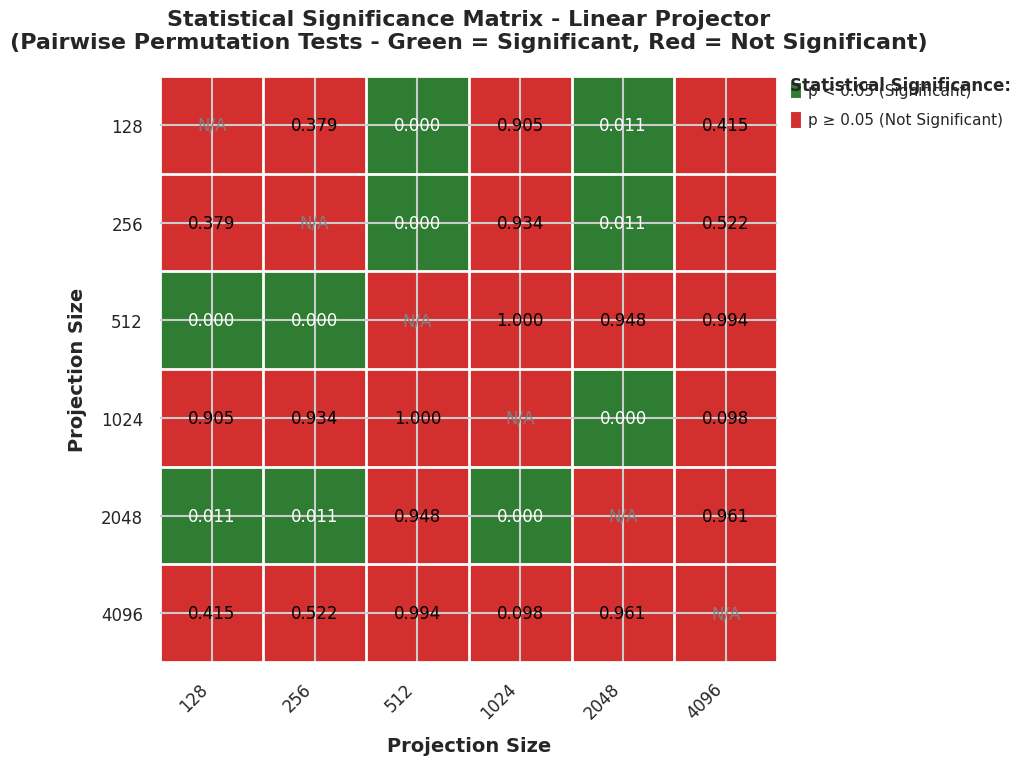


✓ Significance matrix plot saved to: linear_projection_significance_matrix.png


In [52]:
# Create significance matrix for Linear Projector
import matplotlib.pyplot as plt
import seaborn as sns

# Create p-value matrix
p_value_matrix_linear = np.ones((n_projections, n_projections))

for _, row in comparison_results_linear.iterrows():
    i = projection_sizes.index(row['projection_size_1'])
    j = projection_sizes.index(row['projection_size_2'])
    p_value_matrix_linear[i, j] = row['p_value']
    p_value_matrix_linear[j, i] = row['p_value']  # Make symmetric

# Create the heatmap
fig, ax = plt.subplots(1, 1, figsize=(10, 8), facecolor='white')

# Create binary significance matrix for visualization
significance_matrix_linear = (p_value_matrix_linear < SIGNIFICANCE_LEVEL).astype(int)

# Use a custom colormap: red for not significant, green for significant
colors = ['#D32F2F', '#2E7D32']  # Red, Green
cmap = plt.matplotlib.colors.ListedColormap(colors)

# Plot the heatmap
im = ax.imshow(significance_matrix_linear, cmap=cmap, aspect='auto', vmin=0, vmax=1)

# Add p-value annotations
for i in range(n_projections):
    for j in range(n_projections):
        if i != j:
            # Choose text color based on background
            text_color = 'white' if significance_matrix_linear[i, j] == 1 else 'black'
            ax.text(j, i, f'{p_value_matrix_linear[i, j]:.3f}',
                   ha='center', va='center',
                   fontsize=12,
                   color=text_color,
                   fontweight='500')
        else:
            # Diagonal - mark as N/A
            ax.text(j, i, 'N/A',
                   ha='center', va='center',
                   fontsize=12,
                   color='gray',
                   fontweight='500')

# Set ticks and labels
proj_labels = [str(ps) for ps in projection_sizes]
ax.set_xticks(range(n_projections))
ax.set_yticks(range(n_projections))
ax.set_xticklabels(proj_labels, rotation=45, ha='right', fontsize=12, fontweight='500')
ax.set_yticklabels(proj_labels, fontsize=12, fontweight='500')

# Labels and title
ax.set_xlabel('Projection Size', fontsize=14, fontweight='600', labelpad=10)
ax.set_ylabel('Projection Size', fontsize=14, fontweight='600', labelpad=10)
ax.set_title('Statistical Significance Matrix - Linear Projector\n(Pairwise Permutation Tests - Green = Significant, Red = Not Significant)',
             fontsize=16, pad=20, fontweight='bold')

# Add grid
ax.set_xticks(np.arange(-0.5, n_projections, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_projections, 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Add colorbar legend
from matplotlib.patches import Rectangle
legend_labels = [
    f'p < {SIGNIFICANCE_LEVEL} (Significant)',
    f'p ≥ {SIGNIFICANCE_LEVEL} (Not Significant)'
]
legend_colors = ['#2E7D32', '#D32F2F']

ax.text(1.02, 1.0, "Statistical Significance:", transform=ax.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='left')

for i, (color, label) in enumerate(zip(legend_colors, legend_labels)):
    y_pos = 0.96 - i * 0.05
    rect = Rectangle((1.02, y_pos), 0.02, 0.03,
                     facecolor=color, transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(1.05, y_pos + 0.015, label,
            transform=ax.transAxes, fontsize=11, va='center', ha='left',
            fontweight='500')

plt.tight_layout()
plt.savefig('/home/fsoto/Documents/LCsSSL/wandb_csv/linear_projection_significance_matrix.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Significance matrix plot saved to: linear_projection_significance_matrix.png")

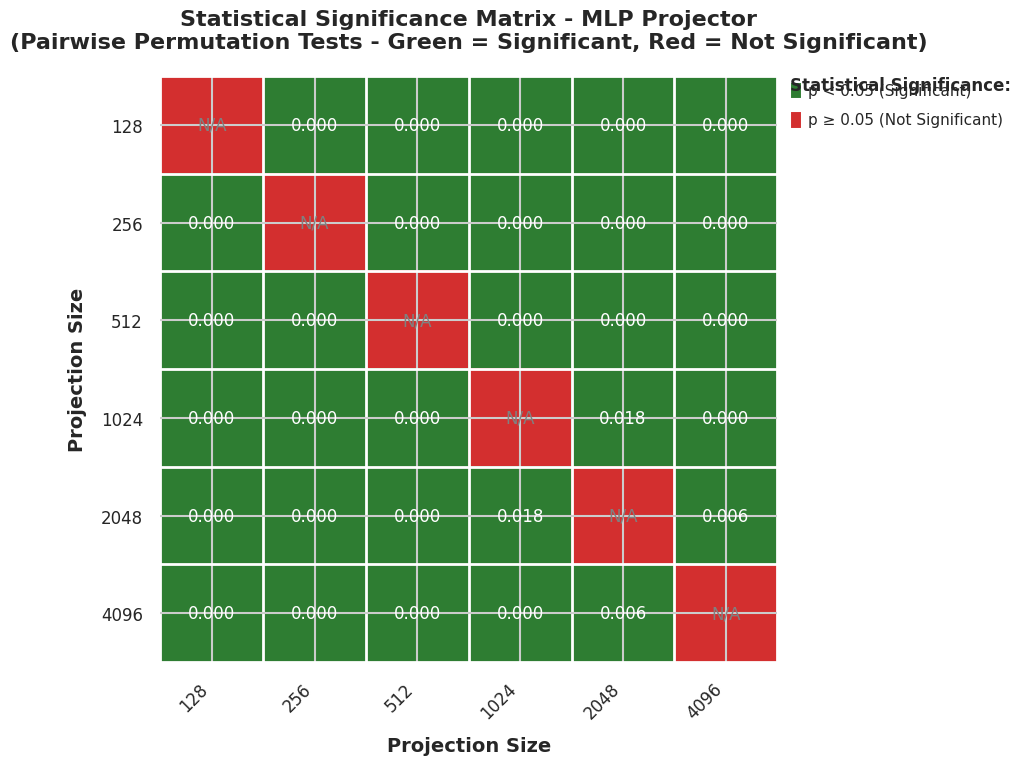


✓ Significance matrix plot saved to: mlp_projection_significance_matrix.png


In [53]:
# Create significance matrix for MLP Projector
# Create p-value matrix
p_value_matrix_mlp = np.ones((n_projections, n_projections))

for _, row in comparison_results_mlp.iterrows():
    i = projection_sizes.index(row['projection_size_1'])
    j = projection_sizes.index(row['projection_size_2'])
    p_value_matrix_mlp[i, j] = row['p_value']
    p_value_matrix_mlp[j, i] = row['p_value']  # Make symmetric

# Create the heatmap
fig, ax = plt.subplots(1, 1, figsize=(10, 8), facecolor='white')

# Create binary significance matrix for visualization
significance_matrix_mlp = (p_value_matrix_mlp < SIGNIFICANCE_LEVEL).astype(int)

# Use a custom colormap: red for not significant, green for significant
colors = ['#D32F2F', '#2E7D32']  # Red, Green
cmap = plt.matplotlib.colors.ListedColormap(colors)

# Plot the heatmap
im = ax.imshow(significance_matrix_mlp, cmap=cmap, aspect='auto', vmin=0, vmax=1)

# Add p-value annotations
for i in range(n_projections):
    for j in range(n_projections):
        if i != j:
            # Choose text color based on background
            text_color = 'white' if significance_matrix_mlp[i, j] == 1 else 'black'
            ax.text(j, i, f'{p_value_matrix_mlp[i, j]:.3f}',
                   ha='center', va='center',
                   fontsize=12,
                   color=text_color,
                   fontweight='500')
        else:
            # Diagonal - mark as N/A
            ax.text(j, i, 'N/A',
                   ha='center', va='center',
                   fontsize=12,
                   color='gray',
                   fontweight='500')

# Set ticks and labels
proj_labels = [str(ps) for ps in projection_sizes]
ax.set_xticks(range(n_projections))
ax.set_yticks(range(n_projections))
ax.set_xticklabels(proj_labels, rotation=45, ha='right', fontsize=12, fontweight='500')
ax.set_yticklabels(proj_labels, fontsize=12, fontweight='500')

# Labels and title
ax.set_xlabel('Projection Size', fontsize=14, fontweight='600', labelpad=10)
ax.set_ylabel('Projection Size', fontsize=14, fontweight='600', labelpad=10)
ax.set_title('Statistical Significance Matrix - MLP Projector\n(Pairwise Permutation Tests - Green = Significant, Red = Not Significant)',
             fontsize=16, pad=20, fontweight='bold')

# Add grid
ax.set_xticks(np.arange(-0.5, n_projections, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_projections, 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Add colorbar legend
from matplotlib.patches import Rectangle
legend_labels = [
    f'p < {SIGNIFICANCE_LEVEL} (Significant)',
    f'p ≥ {SIGNIFICANCE_LEVEL} (Not Significant)'
]
legend_colors = ['#2E7D32', '#D32F2F']

ax.text(1.02, 1.0, "Statistical Significance:", transform=ax.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='left')

for i, (color, label) in enumerate(zip(legend_colors, legend_labels)):
    y_pos = 0.96 - i * 0.05
    rect = Rectangle((1.02, y_pos), 0.02, 0.03,
                     facecolor=color, transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(1.05, y_pos + 0.015, label,
            transform=ax.transAxes, fontsize=11, va='center', ha='left',
            fontweight='500')

plt.tight_layout()
plt.savefig('/home/fsoto/Documents/LCsSSL/wandb_csv/mlp_projection_significance_matrix.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Significance matrix plot saved to: mlp_projection_significance_matrix.png")